# This example aims to show how Effects of Site (EoS) can be problematic for ML.
EoS can have two rather opposite effects to ML pipelines.

- The first effect is to **hinder** the real true signal. In this cases, the ML model have harder time to find the true signal, thus removing EoS should *improve* our classification, as the signal-to-noise ratio should improve.

- The second effect is to **confound** the true signal. In this cases, the ML model can *use* the EoS signal to fraudulently improve the performance, as the predictions will not be based on true biological signal but rather on site effects. In such cases, removing the EoS will *reduce* the model's performance. 

In [ ]:
import logging

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import structlog
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

from uniharmony.combat import NeuroComBat
from uniharmony.datasets import make_multisite_classification


# To only get the necessary info from structlog, we configure it to filter out messages below INFO level.
structlog.configure(wrapper_class=structlog.make_filtering_bound_logger(logging.INFO))
combat = NeuroComBat()
clf = LogisticRegression()
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

In [49]:
def plot_decision_boundery(ax, clf):
    """Plot 2D decision boundery for methods that provide it."""
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 100), np.linspace(ylim[0], ylim[1], 100))
    Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contour(xx, yy, Z, levels=[0], colors="black", linewidths=1, alpha=0.7)

Mean AUC: 0.9043


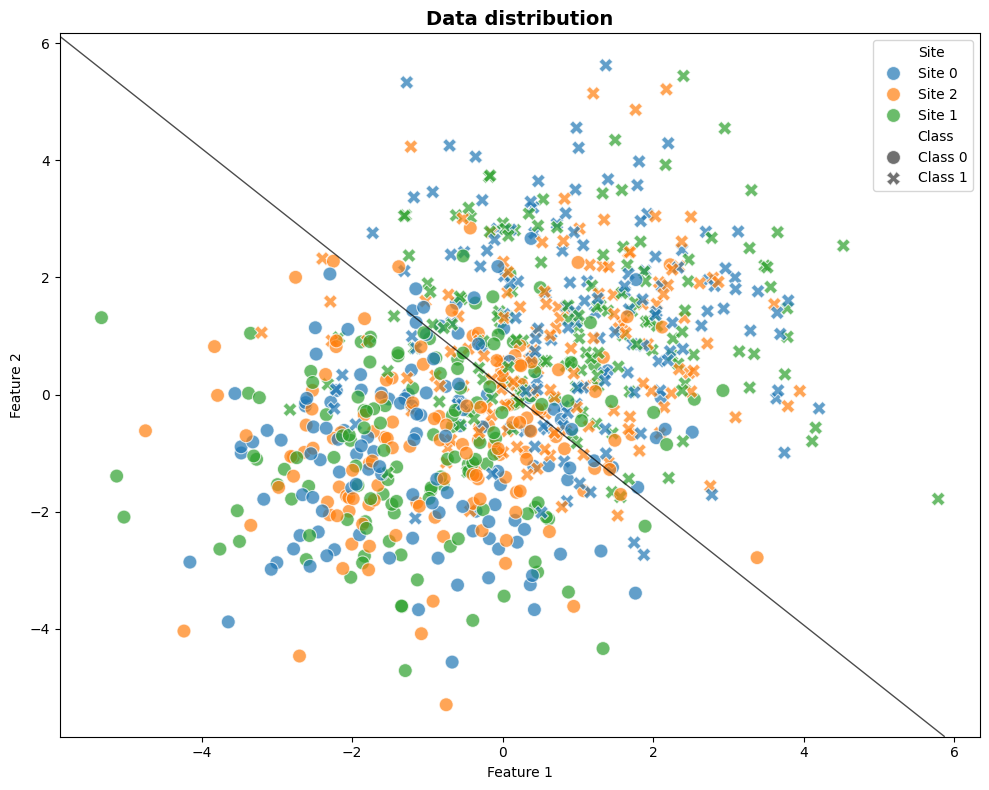

In [ ]:
X, y, sites = make_multisite_classification(
    n_classes=2,
    n_samples=800,
    n_sites=3,
    n_features=2,
    signal_strength=2,
    site_effect_strength=0,
)
# Create DataFrame for easier plotting
df = pd.DataFrame(
    {"Feature 1": X[:, 0], "Feature 2": X[:, 1], "Class": [f"Class {c}" for c in y], "Site": [f"Site {s}" for s in sites]}
)

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Plot with site as hue and class as style
sns.scatterplot(data=df, x="Feature 1", y="Feature 2", hue="Site", style="Class", s=100, alpha=0.7, ax=ax)

ax.set_title("Data distribution", fontsize=14, fontweight="bold")

plt.tight_layout()
clf.fit(X, y)
plot_decision_boundery(ax, clf)

# Perform 10-fold stratified cross-validation
scores = cross_val_score(clf, X, y, cv=cv, scoring="roc_auc")
print(f"Mean AUC: {scores.mean():.4f}")

Mean AUC: 0.8265


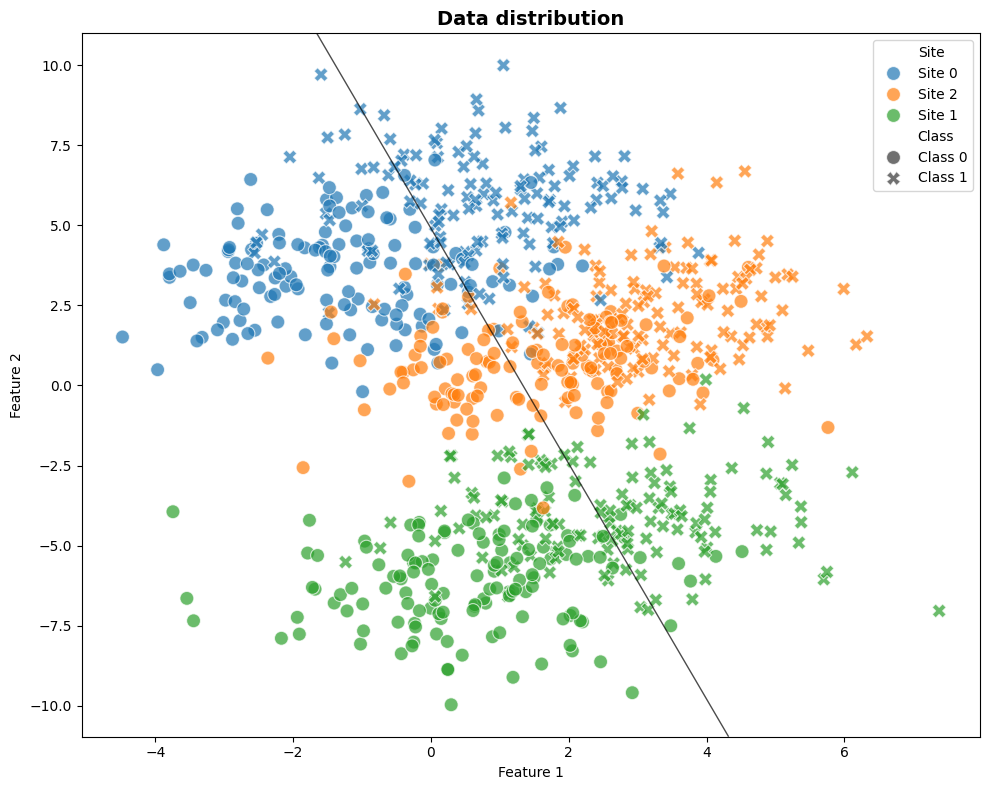

In [52]:
X, y, sites = make_multisite_classification(
    n_classes=2,
    n_samples=800,
    n_sites=3,
    n_features=2,
    signal_strength=2,
    site_effect_strength=4,
)
# Test the visualization
fig, ax = plt.subplots(1, 1, figsize=(10, 8))


# Create DataFrame for easier plotting
df = pd.DataFrame(
    {"Feature 1": X[:, 0], "Feature 2": X[:, 1], "Class": [f"Class {c}" for c in y], "Site": [f"Site {s}" for s in sites]}
)

# Plot with site as hue and class as style
sns.scatterplot(data=df, x="Feature 1", y="Feature 2", hue="Site", style="Class", s=100, alpha=0.7, ax=ax)

ax.set_title("Data distribution", fontsize=14, fontweight="bold")

# Calculate and display metrics
# Class separability ( silhouette-like metric using centroids)
class_centroids = []
for c in np.unique(y):
    class_centroids.append(X[y == c].mean(axis=0))
class_centroids = np.array(class_centroids)
class_separation = np.linalg.norm(class_centroids[0] - class_centroids[1])

# Site effect magnitude (average distance between site centroids)
site_centroids = []
for s in np.unique(sites):
    site_centroids.append(X[sites == s].mean(axis=0))
site_centroids = np.array(site_centroids)
site_separation = np.mean(
    [
        np.linalg.norm(site_centroids[i] - site_centroids[j])
        for i in range(len(site_centroids))
        for j in range(i + 1, len(site_centroids))
    ]
)

plt.tight_layout()
clf.fit(X, y)
plot_decision_boundery(ax, clf)
# Perform 10-fold stratified cross-validation
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_val_score(clf, X, y, cv=cv, scoring="roc_auc")

print(f"Mean AUC: {scores.mean():.4f}")

We don't have real signal, and the sites are distributed
Mean accuracy: 0.4583


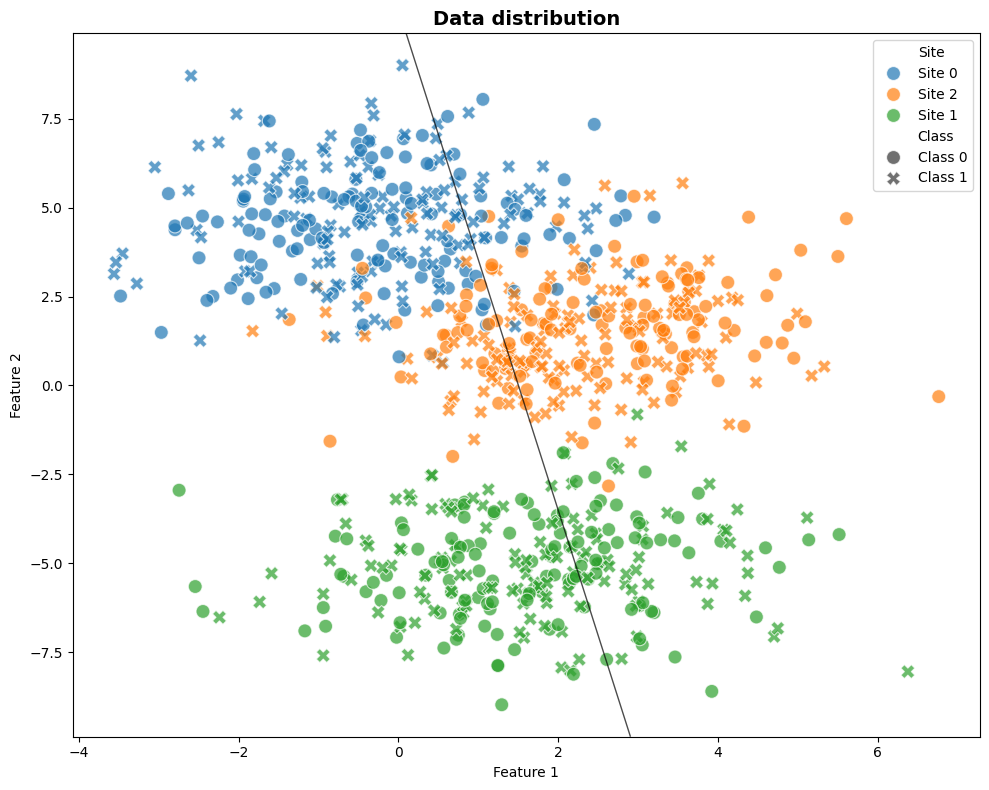

In [53]:
X, y, sites = make_multisite_classification(
    n_classes=2,
    n_samples=800,
    n_sites=3,
    n_features=2,
    signal_strength=0,
    site_effect_strength=4,
)

# Test the visualization
fig, ax = plt.subplots(1, 1, figsize=(10, 8))


# Create DataFrame for easier plotting
df = pd.DataFrame(
    {"Feature 1": X[:, 0], "Feature 2": X[:, 1], "Class": [f"Class {c}" for c in y], "Site": [f"Site {s}" for s in sites]}
)

# Plot with site as hue and class as style
sns.scatterplot(data=df, x="Feature 1", y="Feature 2", hue="Site", style="Class", s=100, alpha=0.7, ax=ax)

ax.set_title("Data distribution", fontsize=14, fontweight="bold")

# Calculate and display metrics
# Class separability ( silhouette-like metric using centroids)
class_centroids = []
for c in np.unique(y):
    class_centroids.append(X[y == c].mean(axis=0))
class_centroids = np.array(class_centroids)
class_separation = np.linalg.norm(class_centroids[0] - class_centroids[1])

# Site effect magnitude (average distance between site centroids)
site_centroids = []
for s in np.unique(sites):
    site_centroids.append(X[sites == s].mean(axis=0))
site_centroids = np.array(site_centroids)
site_separation = np.mean(
    [
        np.linalg.norm(site_centroids[i] - site_centroids[j])
        for i in range(len(site_centroids))
        for j in range(i + 1, len(site_centroids))
    ]
)

plt.tight_layout()
clf.fit(X, y)
plot_decision_boundery(ax, clf)
# Perform 10-fold stratified cross-validation
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_val_score(clf, X, y, cv=cv, scoring="roc_auc")

print("We don't have real signal, and the sites are distributed")
print(f"Mean accuracy: {scores.mean():.4f}")

We don't have real signal, and the sites are distributed
Mean accuracy: 0.7094


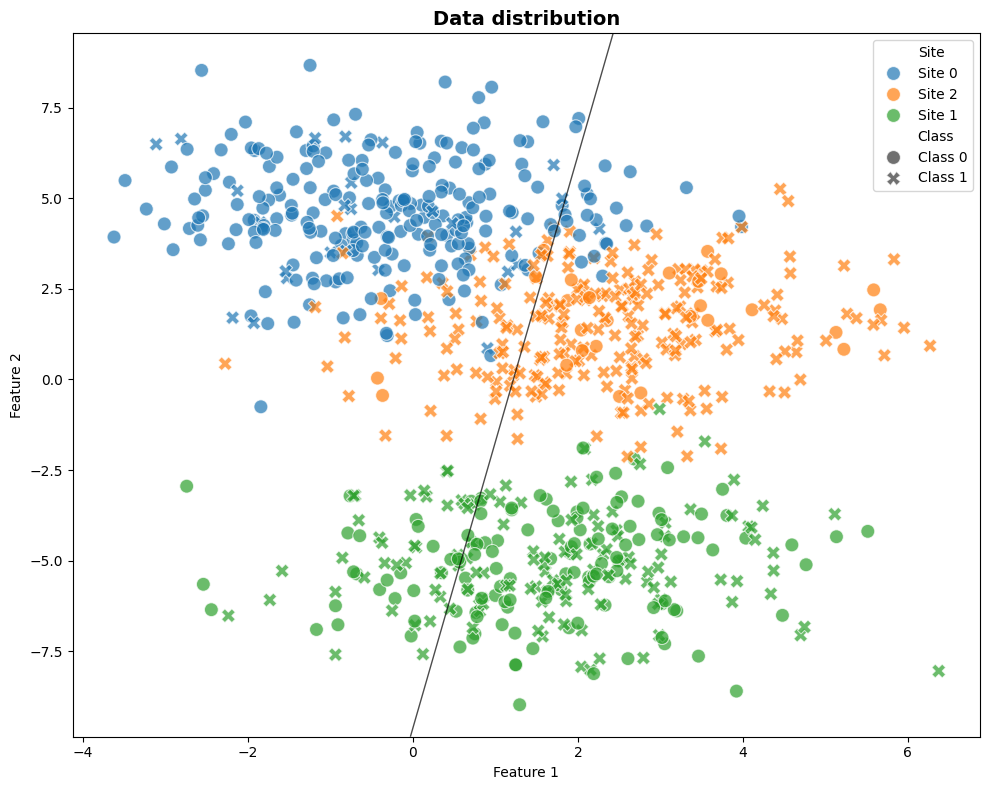

In [54]:
X, y, sites = make_multisite_classification(
    n_classes=2,
    n_samples=800,
    n_sites=3,
    n_features=2,
    signal_strength=0,
    site_effect_strength=4,
    balance_per_site=[0.1, 0.5, 0.9],
)

# Test the visualization
fig, ax = plt.subplots(1, 1, figsize=(10, 8))


# Create DataFrame for easier plotting
df = pd.DataFrame(
    {"Feature 1": X[:, 0], "Feature 2": X[:, 1], "Class": [f"Class {c}" for c in y], "Site": [f"Site {s}" for s in sites]}
)

# Plot with site as hue and class as style
sns.scatterplot(data=df, x="Feature 1", y="Feature 2", hue="Site", style="Class", s=100, alpha=0.7, ax=ax)

ax.set_title("Data distribution", fontsize=14, fontweight="bold")

# Calculate and display metrics
# Class separability ( silhouette-like metric using centroids)
class_centroids = []
for c in np.unique(y):
    class_centroids.append(X[y == c].mean(axis=0))
class_centroids = np.array(class_centroids)
class_separation = np.linalg.norm(class_centroids[0] - class_centroids[1])

# Site effect magnitude (average distance between site centroids)
site_centroids = []
for s in np.unique(sites):
    site_centroids.append(X[sites == s].mean(axis=0))
site_centroids = np.array(site_centroids)
site_separation = np.mean(
    [
        np.linalg.norm(site_centroids[i] - site_centroids[j])
        for i in range(len(site_centroids))
        for j in range(i + 1, len(site_centroids))
    ]
)

plt.tight_layout()
# Perform 10-fold stratified cross-validation
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_val_score(clf, X, y, cv=cv, scoring="roc_auc")

clf.fit(X, y)
plot_decision_boundery(ax, clf)
print("We don't have real signal, and the sites are distributed")
print(f"Mean accuracy: {scores.mean():.4f}")

We don't have real signal, and the sites are distributed
Mean accuracy: 0.5198


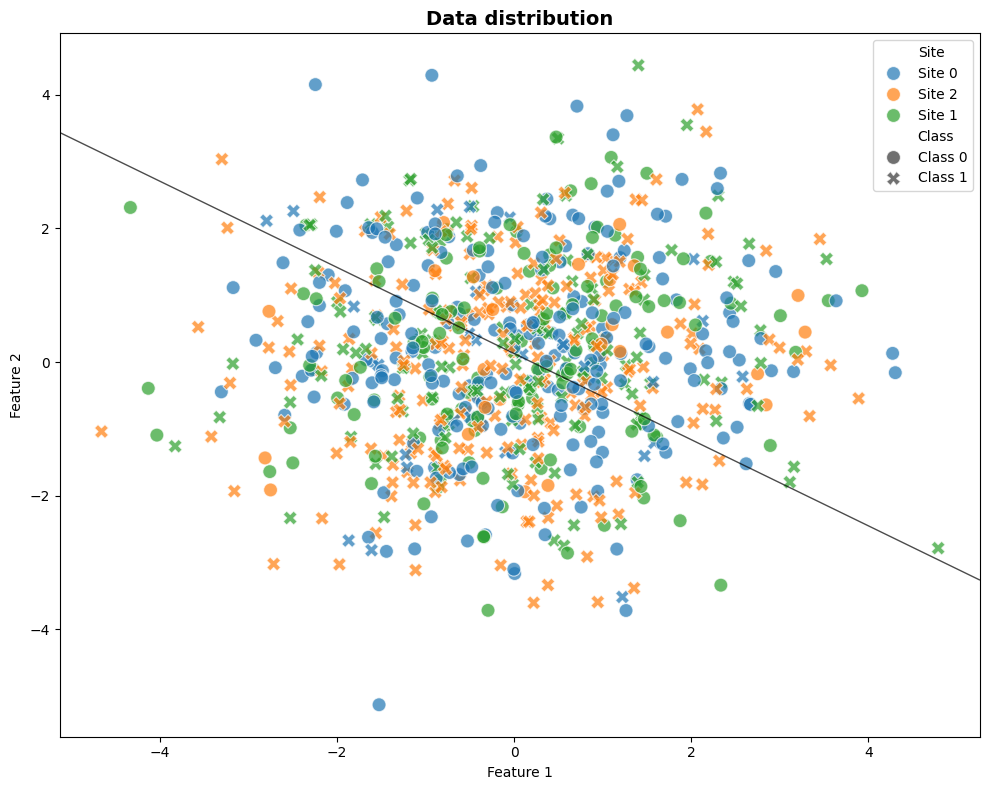

In [55]:
X, y, sites = make_multisite_classification(
    n_classes=2,
    n_samples=800,
    n_sites=3,
    n_features=2,
    signal_strength=0,
    site_effect_strength=0,
    balance_per_site=[0.1, 0.5, 0.9],
)

# Test the visualization
fig, ax = plt.subplots(1, 1, figsize=(10, 8))


# Create DataFrame for easier plotting
df = pd.DataFrame(
    {"Feature 1": X[:, 0], "Feature 2": X[:, 1], "Class": [f"Class {c}" for c in y], "Site": [f"Site {s}" for s in sites]}
)

# Plot with site as hue and class as style
sns.scatterplot(data=df, x="Feature 1", y="Feature 2", hue="Site", style="Class", s=100, alpha=0.7, ax=ax)

ax.set_title("Data distribution", fontsize=14, fontweight="bold")

# Calculate and display metrics
# Class separability ( silhouette-like metric using centroids)
class_centroids = []
for c in np.unique(y):
    class_centroids.append(X[y == c].mean(axis=0))
class_centroids = np.array(class_centroids)
class_separation = np.linalg.norm(class_centroids[0] - class_centroids[1])

# Site effect magnitude (average distance between site centroids)
site_centroids = []
for s in np.unique(sites):
    site_centroids.append(X[sites == s].mean(axis=0))
site_centroids = np.array(site_centroids)
site_separation = np.mean(
    [
        np.linalg.norm(site_centroids[i] - site_centroids[j])
        for i in range(len(site_centroids))
        for j in range(i + 1, len(site_centroids))
    ]
)

plt.tight_layout()
# Perform 10-fold stratified cross-validation
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_val_score(clf, X, y, cv=cv, scoring="roc_auc")

clf.fit(X, y)
plot_decision_boundery(ax, clf)
print("We don't have real signal, and the sites are distributed")
print(f"Mean accuracy: {scores.mean():.4f}")

We don't have real signal, and the sites are distributed
Mean accuracy: 0.5198


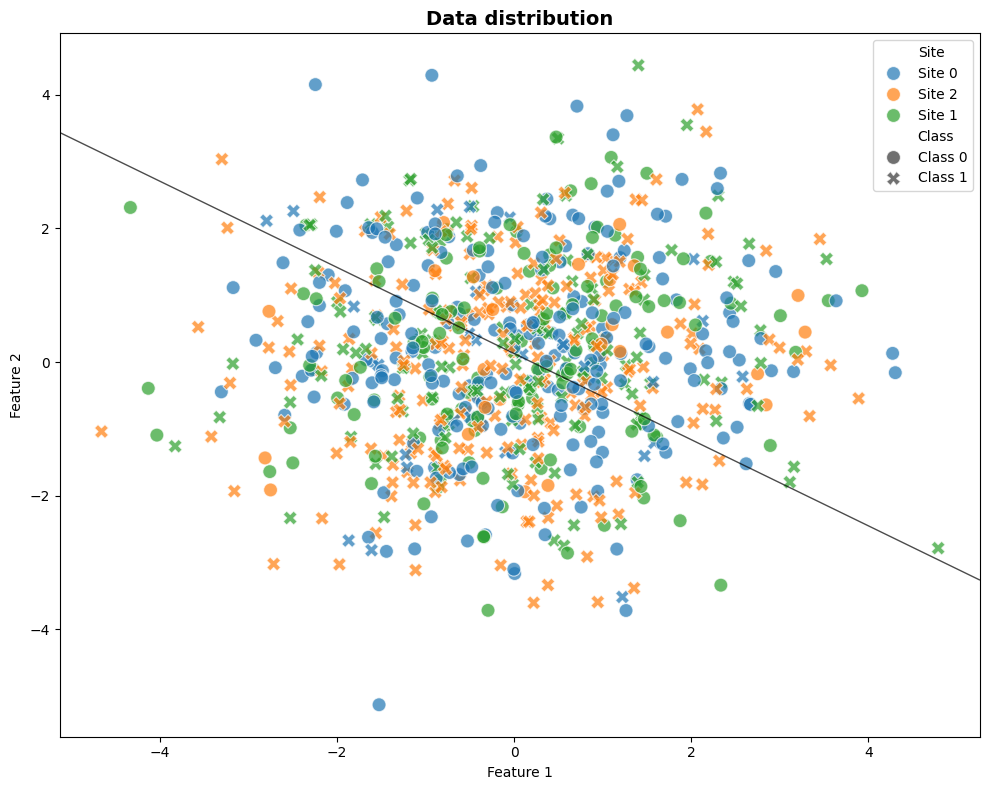

In [ ]:
X, y, sites = make_multisite_classification(
    n_classes=2,
    n_samples=800,
    n_sites=3,
    n_features=2,
    signal_strength=0,
    site_effect_strength=0,
    balance_per_site=[0.1, 0.5, 0.9],
)

# Test the visualization
fig, ax = plt.subplots(1, 1, figsize=(10, 8))


# Create DataFrame for easier plotting
df = pd.DataFrame(
    {"Feature 1": X[:, 0], "Feature 2": X[:, 1], "Class": [f"Class {c}" for c in y], "Site": [f"Site {s}" for s in sites]}
)

# Plot with site as hue and class as style
sns.scatterplot(data=df, x="Feature 1", y="Feature 2", hue="Site", style="Class", s=100, alpha=0.7, ax=ax)

ax.set_title("Data distribution", fontsize=14, fontweight="bold")

# Calculate and display metrics
# Class separability ( silhouette-like metric using centroids)
class_centroids = []
for c in np.unique(y):
    class_centroids.append(X[y == c].mean(axis=0))
class_centroids = np.array(class_centroids)
class_separation = np.linalg.norm(class_centroids[0] - class_centroids[1])

# Site effect magnitude (average distance between site centroids)
site_centroids = []
for s in np.unique(sites):
    site_centroids.append(X[sites == s].mean(axis=0))
site_centroids = np.array(site_centroids)
site_separation = np.mean(
    [
        np.linalg.norm(site_centroids[i] - site_centroids[j])
        for i in range(len(site_centroids))
        for j in range(i + 1, len(site_centroids))
    ]
)

plt.tight_layout()
# Perform 10-fold stratified cross-validation
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_val_score(clf, X, y, cv=cv, scoring="roc_auc")

clf.fit(X, y)
plot_decision_boundery(ax, clf)
print("We don't have real signal, and the sites are distributed")
print(f"Mean accuracy: {scores.mean():.4f}")